In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csiborgtools
import healpy as hp

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [5]:
# reader = csiborgtools.read.CSiBORG2Field(17417, "main")
reader = csiborgtools.read.Carrick2015Field()

# field = reader.density_field(MAS="SPH", grid=1024)
field = reader.radial_velocity_field(MAS="SPH", grid=1024)

2025-03-20 18:54:13,867 computing the radial velocity field.


In [7]:
nside = 128
npix = hp.nside2npix(nside)
theta, phi = hp.pix2ang(nside, np.arange(npix))

ra = np.rad2deg(phi)
dec = np.rad2deg(np.pi/2 - theta)

el, b = csiborgtools.radec_to_galactic(ra, dec)
angpos = np.array([el, b]).T
# angpos = np.array([ra, dec]).T

rmin = 85 * 0.6771
rmax = 150 * 0.6771
dr = 0.1
boxsize = csiborgtools.simname2boxsize("Carrick2015")
# boxsize = csiborgtools.simname2boxsize("csiborg2_main")

field_map = csiborgtools.field.make_sky(field, angpos, rmin, rmax, dr, boxsize)


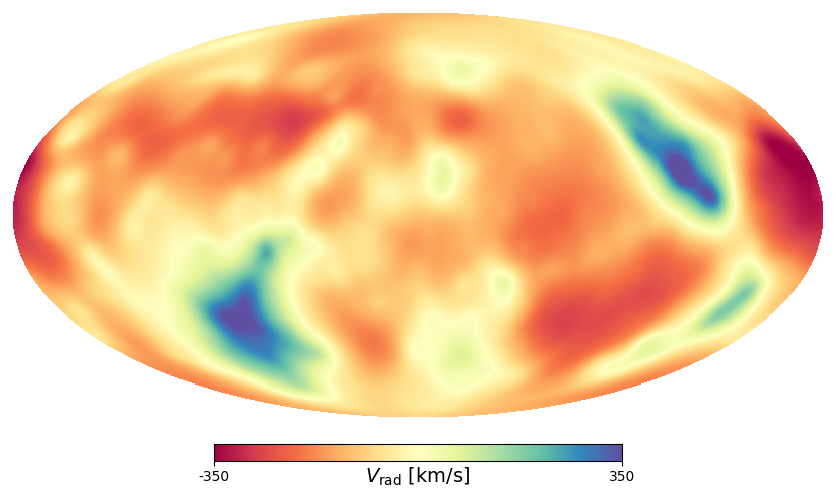

In [24]:
hp.mollview(np.clip(field_map * 0.4, -350, 350), rot=0, cmap="Spectral", title="", cbar=True,
            unit=r"$V_{\rm rad} ~ [\mathrm{km} / \mathrm{s}]$",) 
plt.savefig("carrick_projection.png", dpi=500, bbox_inches="tight")